In [1]:
from diffusers import StableDiffusionPipeline
import torch

model_id = "sd-legacy/stable-diffusion-v1-5"
pipe = StableDiffusionPipeline.from_pretrained(model_id, torch_dtype=torch.float16)
#load SD3.5
# pipe = StableDiffusionPipeline.from_pretrained("runwayml/stable-diffusion-v1-5", torch_dtype=torch.float16)
pipe = pipe.to("cuda")

prompt = "a photo of an astronaut riding a horse on mars"
image = pipe(prompt).images[0]  

#print image dimensions
print(image.size)
    
image.save("astronaut_rides_horse.png")

/media/aris/Data/master2025dev/aris_master/.venv/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
100%|██████████| 50/50 [00:02<00:00, 17.80it/s]


(512, 512)


In [3]:
#pipe.unet
pipe

# print the hidden dimensions of the unet
print(pipe.unet.config)

total_params = sum(p.numel() for p in pipe.unet.parameters())
print(f"Total parameters: {total_params:,}")
text_embedding_params = sum(p.numel() for p in pipe.text_encoder.parameters())
print(f"Text embedding parameters: {text_embedding_params:,}")

#number of parameters in the unet
unet_params = sum(p.numel() for p in pipe.unet.parameters())
print(f"UNet parameters: {unet_params:,}")


FrozenDict([('sample_size', 64), ('in_channels', 4), ('out_channels', 4), ('center_input_sample', False), ('flip_sin_to_cos', True), ('freq_shift', 0), ('down_block_types', ['CrossAttnDownBlock2D', 'CrossAttnDownBlock2D', 'CrossAttnDownBlock2D', 'DownBlock2D']), ('mid_block_type', 'UNetMidBlock2DCrossAttn'), ('up_block_types', ['UpBlock2D', 'CrossAttnUpBlock2D', 'CrossAttnUpBlock2D', 'CrossAttnUpBlock2D']), ('only_cross_attention', False), ('block_out_channels', [320, 640, 1280, 1280]), ('layers_per_block', 2), ('downsample_padding', 1), ('mid_block_scale_factor', 1), ('dropout', 0.0), ('act_fn', 'silu'), ('norm_num_groups', 32), ('norm_eps', 1e-05), ('cross_attention_dim', 768), ('transformer_layers_per_block', 1), ('reverse_transformer_layers_per_block', None), ('encoder_hid_dim', None), ('encoder_hid_dim_type', None), ('attention_head_dim', 8), ('num_attention_heads', None), ('dual_cross_attention', False), ('use_linear_projection', False), ('class_embed_type', None), ('addition_emb

In [1]:
from diffusers import UNet2DModel
resolution = 128
model = UNet2DModel(
            sample_size=resolution,  # 8x downsampling
            in_channels=4,
            out_channels=4,
            layers_per_block=2,
            block_out_channels=(320, 640, 1280, 1280),
            down_block_types=(
                "DownBlock2D",
                "AttnDownBlock2D",
                "AttnDownBlock2D",
                "DownBlock2D",
            ),
            up_block_types=(
                "UpBlock2D",
                "AttnUpBlock2D",
                "AttnUpBlock2D",
                "UpBlock2D",
            ),
)

/media/aris/Data/master2025dev/aris_master/.venv/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [14]:
prompt = "a photo of an astronaut riding a horse on mars"

encoded_prompt = pipe.tokenizer(prompt, padding="max_length", max_length=pipe.tokenizer.model_max_length, truncation=True, return_tensors="pt").input_ids
encoded_prompt = pipe.tokenizer(prompt, return_tensors="pt").input_ids
print(encoded_prompt.shape)
embeddings = pipe.text_encoder(encoded_prompt.to(pipe.device))
print(embeddings.last_hidden_state.shape)


torch.Size([1, 12])
torch.Size([1, 12, 768])


In [7]:
pipe.tokenizer?

Signature:     
pipe.tokenizer(
    text: 'TextInput | PreTokenizedInput | list[TextInput] | list[PreTokenizedInput] | None' = None,
    text_pair: 'TextInput | PreTokenizedInput | list[TextInput] | list[PreTokenizedInput] | None' = None,
    text_target: 'TextInput | PreTokenizedInput | list[TextInput] | list[PreTokenizedInput] | None' = None,
    text_pair_target: 'TextInput | PreTokenizedInput | list[TextInput] | list[PreTokenizedInput] | None' = None,
    add_special_tokens: 'bool' = True,
    padding: 'bool | str | PaddingStrategy' = False,
    truncation: 'bool | str | TruncationStrategy | None' = None,
    max_length: 'int | None' = None,
    stride: 'int' = 0,
    is_split_into_words: 'bool' = False,
    pad_to_multiple_of: 'int | None' = None,
    padding_side: 'str | None' = None,
    return_tensors: 'str | TensorType | None' = None,
    return_token_type_ids: 'bool | None' = None,
    return_attention_mask: 'bool | None' = None,
    return_overflowing_tokens: 'bool' = False,

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-1.7922626..1.9303362].


torch.Size([1, 3, 224, 224])


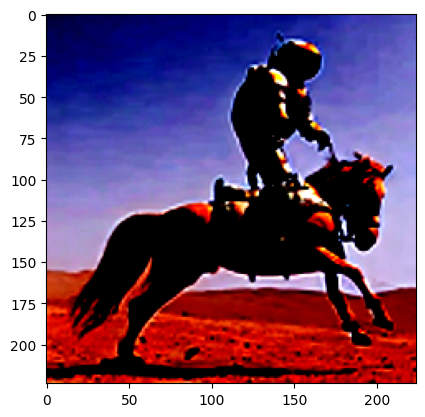

torch.Size([1, 12, 768])
CLIPTextModel(
  (embeddings): CLIPTextEmbeddings(
    (token_embedding): Embedding(49408, 768)
    (position_embedding): Embedding(77, 768)
  )
  (encoder): CLIPEncoder(
    (layers): ModuleList(
      (0-11): 12 x CLIPEncoderLayer(
        (self_attn): CLIPAttention(
          (k_proj): Linear(in_features=768, out_features=768, bias=True)
          (v_proj): Linear(in_features=768, out_features=768, bias=True)
          (q_proj): Linear(in_features=768, out_features=768, bias=True)
          (out_proj): Linear(in_features=768, out_features=768, bias=True)
        )
        (layer_norm1): LayerNorm((768,), eps=1e-05, elementwise_affine=True)
        (mlp): CLIPMLP(
          (activation_fn): QuickGELUActivation()
          (fc1): Linear(in_features=768, out_features=3072, bias=True)
          (fc2): Linear(in_features=3072, out_features=768, bias=True)
        )
        (layer_norm2): LayerNorm((768,), eps=1e-05, elementwise_affine=True)
      )
    )
  )
  (f

AttributeError: 'CLIPTextModel' object has no attribute 'text_model'

In [ ]:
#pipe.feature_extractor?
import PIL


image = PIL.Image.open("astronaut_rides_horse.png").convert("RGB")
# resize the image to 128x128
image = image.resize((128, 128))

# extract the image features
image_features = pipe.feature_extractor(image, return_tensors="pt").pixel_values
print(image_features.shape) # [1, 3, 224, 224]
#plot the image features
import matplotlib.pyplot as plt
plt.imshow(image_features[0].permute(1, 2, 0)) # permute to (224, 224, 3) for plotting
plt.show()

# extract the text features
text_features = pipe.text_encoder(encoded_prompt.to(pipe.device)).last_hidden_state
print(text_features.shape) # [1, 12, 768]

# extract the weights used for mapping the text features and the image features to the same dimension
print(pipe.text_encoder)
print(pipe.feature_extractor)
projection_layer = pipe.text_encoder.text_model.embeddings.position_embedding # Position embeddings


Loading weights: 100%|██████████| 199/199 [00:00<00:00, 57674.58it/s]
[transformers] CLIPVisionModel LOAD REPORT from: openai/clip-vit-base-patch32
Key                                                          | Status     |  | 
-------------------------------------------------------------+------------+--+-
text_model.encoder.layers.{0...11}.layer_norm1.weight        | UNEXPECTED |  | 
text_model.encoder.layers.{0...11}.self_attn.v_proj.bias     | UNEXPECTED |  | 
text_model.encoder.layers.{0...11}.layer_norm1.bias          | UNEXPECTED |  | 
text_model.encoder.layers.{0...11}.self_attn.out_proj.weight | UNEXPECTED |  | 
text_model.encoder.layers.{0...11}.layer_norm2.weight        | UNEXPECTED |  | 
text_model.encoder.layers.{0...11}.self_attn.k_proj.bias     | UNEXPECTED |  | 
text_model.encoder.layers.{0...11}.self_attn.q_proj.bias     | UNEXPECTED |  | 
text_model.encoder.layers.{0...11}.self_attn.out_proj.bias   | UNEXPECTED |  | 
text_model.encoder.layers.{0...11}.layer_norm2.bias 

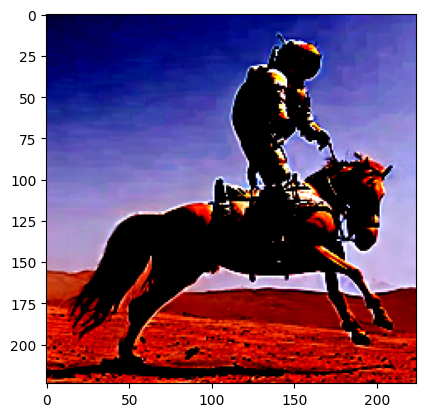

torch.Size([1, 3, 224, 224])
torch.Size([1, 768])


In [28]:
from transformers import CLIPProcessor, CLIPVisionModel
from PIL import Image

# 1. Load the processor and model
processor = CLIPProcessor.from_pretrained("openai/clip-vit-base-patch32")
model = CLIPVisionModel.from_pretrained("openai/clip-vit-base-patch32")

# 2. Preprocess (This results in the 3x224x224 tensor)
inputs = processor(images=image, return_tensors="pt")
#plot the inputs
import matplotlib.pyplot as plt
plt.imshow(inputs['pixel_values'][0].permute(1, 2, 0)) # permute to (224, 224, 3) for plotting
plt.show()
print(inputs['pixel_values'].shape) # Output: torch.Size([1, 3, 224, 224])

# 3. Forward pass to get the actual embedding
outputs = model(**inputs)
image_embeds = outputs.pooler_output
print(image_embeds.shape) # Output: torch.Size([1, 768])

In [1]:
from diffusers import UNet2DModel
config_path = "/media/aris/Data/master2025dev/aris_master/queue/completed/1_04-13_4_class_condtional_500_real.json"
config = UNet2DModel.load_config(config_path)
config["model"]["num_class_embeds"] = 4
print(config["model"])
model = UNet2DModel.from_config(config["model"])

/media/aris/Data/master2025dev/aris_master/.venv/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


KeyboardInterrupt: 

In [24]:
import torch
print(model.class_embedding)
print(model.class_embedding.num_embeddings)
print(model.class_embedding.embedding_dim)
embedding = model.class_embedding(torch.tensor([0]))
print(embedding)
print(embedding.shape)


Embedding(4, 512)
4
512
tensor([[ 0.2251, -1.3084, -1.2122, -0.4337, -0.2783,  0.4469,  0.7329, -1.6566,
         -0.2043, -0.5325,  0.1531, -0.5086,  1.5869,  0.2901,  1.1283, -1.0105,
         -0.6266,  0.3090, -1.1147,  1.0732,  0.6297, -1.0267, -1.0046, -1.5880,
         -1.4418, -1.3416, -0.2021, -0.2284,  1.6675,  1.5240,  0.7582,  1.0004,
         -0.4808, -0.4012, -1.2296,  2.3812,  2.4417, -1.4954,  1.1971,  0.3748,
         -0.0078, -0.1358, -1.1201,  0.3357, -1.5239,  0.4360, -0.0167,  0.2414,
         -1.6212,  1.0744,  0.6746,  0.8323, -0.6281,  0.2935, -0.4863, -1.0276,
          1.1390,  0.8970, -0.7038,  1.1787,  0.6794,  1.4888, -0.1502,  1.6276,
         -0.7686, -0.4478, -0.0865, -0.0065,  1.0891, -0.8522, -0.8931, -0.3594,
         -1.1573,  1.7140, -0.9523,  0.3999,  0.9635,  1.2841, -0.2331,  0.0997,
         -0.0445, -0.5884, -0.1659,  1.4210, -0.6590,  0.9613, -1.2785,  1.1177,
         -0.5988, -0.0291, -0.4457,  0.6851,  0.1245,  1.2244, -0.5064, -0.2981,
    

In [ ]:
#Image embeddings
from PIL import Image
from torchvision import transforms
image = Image.open("astronaut_rides_horse.png").convert("RGB")
transform = transforms.Compose([
    transforms.Resize((resolution, resolution)),
    transforms.ToTensor(),
    transforms.Normalize([0.5], [0.5]),
])
image_tensor = transform(image).unsqueeze(0)  # Add batch dimension
print(image_tensor.shape)

